# Laboratori 10 — Aplikime të Rrjedhës Maksimale: Çiftëzimi Dyanësor dhe Problemet e Caktimit

> **Lidhja me leksionin:** *Leksionet 5–6 — "Por prisni, nuk kemi mbaruar!"* (slides 80–90).
>
> *"Prerja min dhe rrjedha max nuk shërbyen vetëm për SHBA dhe BS në 1955. Algoritmi Ford-Fulkerson është
> baza për shumë algoritme të tjera në grafe."* Në këtë laborator nuk shkruajmë algoritëm të ri:
> **modelojmë** probleme të reja si rrjeta rrjedhë dhe përdorim Edmonds-Karp-in që e ndërtuam në Laboratorin 9.
> Nuk kërkon Pygame.

**Parakushte:** Laboratori 4 (grafet dyanësorë) dhe Laboratori 9 (Ford-Fulkerson, rrjeta mbetëse).

| # | Ushtrimi | Ideja |
|:-:|---|---|
| 1 | Vajzat dhe kotelet | çiftëzimi maksimum = rrjedha max me kapacitete 1 |
| 2 | Pse funksionon? | integraliteti + ruajtja e rrjedhës ⇒ çiftëzim |
| 3 | Lulet dhe buqetat | problem caktimi me kapacitete në kulme dhe në brinjë |
| 4 | Grupet e laboratorit | modelojeni vetë: a mund të vendosen të gjithë studentët? |

## Kujtues teorik — Çiftëzimi dhe problemet e caktimit

Le të jetë $G = (X \cup Y, E)$ një **graf dyanësor** (Laboratori 4): çdo brinjë lidh një kulm të $X$ me një kulm të $Y$.

Një **çiftëzim** $M \subseteq E$ është një bashkësi brinjësh ku **asnjë kulm nuk shfaqet dy herë**.
Një **çiftëzim maksimum** ka numrin më të madh të mundshëm të brinjëve ($\lvert M \rvert$ = kardinali i çiftëzimit).

### Reduktimi në rrjedhë max (slides 83–85)
1. Shtojmë një burim $s$ me brinjë $s \to x$ për çdo $x \in X$;
2. orientojmë çdo brinjë $\{x, y\}$ si $x \to y$;
3. shtojmë një derdhje $t$ me brinjë $y \to t$ për çdo $y \in Y$;
4. **të gjitha brinjët kanë kapacitet 1.**

**Pse funksionon (slide 85):**
1. Kapacitetet janë të plota ⇒ rrjedha max e gjetur nga Ford-Fulkerson është e plotë, pra çdo $f(e) \in \{0, 1\}$.
2. Rrjedha hyrëse = rrjedha dalëse ⇒ çdo $x$ merr të shumtën 1 njësi (nga $s$), pra i caktohet të shumtën një $y$ — dhe anasjelltas.
3. Brinjët $x \to y$ me rrjedhë 1 formojnë një çiftëzim, dhe çdo çiftëzim përcakton një rrjedhë.
4. Vlera e rrjedhës = kardinali i çiftëzimit ⇒ **rrjedha max ↔ çiftëzimi maksimum**.

### Problemet e caktimit (slide 86)
Përgjithësimi: çdo $x \in X$ mund të marrë pjesë në **$c(x)$** çiftime, çdo $y \in Y$ në **$c(y)$** çiftime,
dhe çdo çift $(x, y)$ mund të përdoret **$c(x, y)$** herë. Kapacitetet bëhen: $c(s, x) = c(x)$, $c(y, t) = c(y)$,
$c(x \to y) = c(x, y)$. **Qëllimi:** sa më shumë çiftime.

In [1]:
# ── Mjeti i kontrollit ──────────────────────────────────────────────
# Ekzekutojeni këtë qelizë një herë, në fillim. Pas çdo ushtrimi, qeliza
# "kontrollo(...)" teston funksionin tuaj dhe ju tregon nëse është gati.

def kontrollo(titulli, testet):
    try:
        testet()
    except NotImplementedError:
        print(f"⏳ {titulli}: ende pa plotësuar — zëvendësoni `raise NotImplementedError` me kodin tuaj.")
    except AssertionError as e:
        print(f"✗ {titulli}: {e}")
    except Exception as e:
        print(f"✗ {titulli}: kodi u ndal me gabim  {type(e).__name__}: {e}")
    else:
        print(f"✓ {titulli}: të gjitha testet kaluan!")


# ── Mjeti nga Laboratori 9: Edmonds-Karp (Ford-Fulkerson me BFS) ────
from collections import deque


def rrjedha_max(c, s="s", t="t"):
    """c = {(u, v): kapaciteti}. Kthen (vlera, f) ku f = {(u, v): rrjedha}."""
    f = {e: 0 for e in c}
    adj = {}
    for u, v in c:
        adj.setdefault(u, set()).add(v)
        adj.setdefault(v, set()).add(u)              # për brinjët kthyese
    def mbetes(u, v):
        return c.get((u, v), 0) - f.get((u, v), 0) + f.get((v, u), 0)
    while True:
        prind, radha = {s: None}, deque([s])
        while radha and t not in prind:
            u = radha.popleft()
            for v in sorted(adj.get(u, ()), key=str):
                if v not in prind and mbetes(u, v) > 0:
                    prind[v] = u
                    radha.append(v)
        if t not in prind:
            return sum(f[e] for e in c if e[0] == s) - sum(f[e] for e in c if e[1] == s), f
        rruga, v = [], t
        while prind[v] is not None:
            rruga.append((prind[v], v)); v = prind[v]
        x = min(mbetes(u, v) for u, v in rruga)
        for u, v in rruga:
            kthim = min(x, f.get((v, u), 0))         # së pari zhbëjmë rrjedhë në drejtim të kundërt
            if kthim:
                f[(v, u)] -= kthim
            if x - kthim:
                f[(u, v)] += x - kthim


def prerja_min(c, f, s="s"):
    adj = {}
    for (u, v), cap in c.items():
        if cap - f[(u, v)] > 0: adj.setdefault(u, []).append(v)
        if f[(u, v)] > 0:       adj.setdefault(v, []).append(u)
    S, radha = {s}, deque([s])
    while radha:
        u = radha.popleft()
        for v in adj.get(u, []):
            if v not in S:
                S.add(v); radha.append(v)
    return S

## Ushtrimi 1 — Vajzat dhe kotelet (slides 81–85)

*Çdo vajzë ka preferencat e saj për të adoptuar një nga kotelet. Si mund të bëjmë të lumtura sa më shumë vajza?*

> Preferencat më poshtë janë një shembull i ndërtuar sipas modelit të leksionit.

Para se të përdorim rrjedhën, provojmë idenë "naive": **secila vajzë, me radhë, merr koteleten e parë të lirë që i pëlqen.**

In [2]:
preferencat = {
    "Helena": ["Mace", "Bubi"],
    "Aria":   ["Mace"],
    "Ema":    ["Bubi", "Tigri"],
    "Sara":   ["Lulu", "Tigri"],
    "Maja":   ["Mace", "Lulu"],
}
kotelet = ["Mace", "Bubi", "Lulu", "Tigri", "Pupi"]


def greedy_ciftezim(preferencat):
    zene, M = set(), {}
    for vajza, lista in preferencat.items():
        for kotele in lista:
            if kotele not in zene:
                M[vajza] = kotele; zene.add(kotele); break
    return M

M_naiv = greedy_ciftezim(preferencat)
print("Çiftëzimi naiv:", M_naiv, f"→ {len(M_naiv)} vajza të lumtura")

Çiftëzimi naiv: {'Helena': 'Mace', 'Ema': 'Bubi', 'Sara': 'Lulu'} → 3 vajza të lumtura


**Detyra:**
1. `rrjeta_e_ciftezimit(preferencat)` — ndërtoni fjalorin e kapaciteteve sipas slide 83:
   `("s", vajza)`, `(vajza, kotele)`, `(kotele, "t")`, të gjitha me kapacitet 1.
   Përfshini vetëm kotelet që i pëlqen të paktën një vajzë.
2. `ciftezimi_nga_rrjedha(f, preferencat)` — nga rrjedha max, ktheni fjalorin `{vajza: kotele}` për brinjët
   vajzë → kotele me rrjedhë 1.

In [3]:
def rrjeta_e_ciftezimit(preferencat):
    # PLOTESO
    raise NotImplementedError


def ciftezimi_nga_rrjedha(f, preferencat):
    # PLOTESO
    raise NotImplementedError

In [4]:
def eshte_ciftezim(M, preferencat):
    return all(k in preferencat[v] for v, k in M.items()) and len(set(M.values())) == len(M)


def _testet():
    c = rrjeta_e_ciftezimit(preferencat)
    assert all(x == 1 for x in c.values()), "të gjitha kapacitetet duhet të jenë 1"
    assert len(c) == 5 + 9 + 4, f"rrjeta duhet të ketë 5 + 9 + 4 = 18 brinjë, ju keni {len(c)}"
    assert ("Pupi", "t") not in c, "Pupi nuk e pëlqen askush — nuk duhet të jetë në rrjetë"
    v, f = rrjedha_max(c)
    M = ciftezimi_nga_rrjedha(f, preferencat)
    assert eshte_ciftezim(M, preferencat), f"{M} nuk është çiftëzim i vlefshëm"
    assert len(M) == v == 4, f"çiftëzimi maksimum ka 4 çifte (slide 85: 'Vlera e kësaj rrjedhe është 4'), u morën {len(M)}"
    print("   Çiftëzimi maksimum:", M)

kontrollo("Ushtrimi 1 — Vajzat dhe kotelet", _testet)

⏳ Ushtrimi 1 — Vajzat dhe kotelet: ende pa plotësuar — zëvendësoni `raise NotImplementedError` me kodin tuaj.


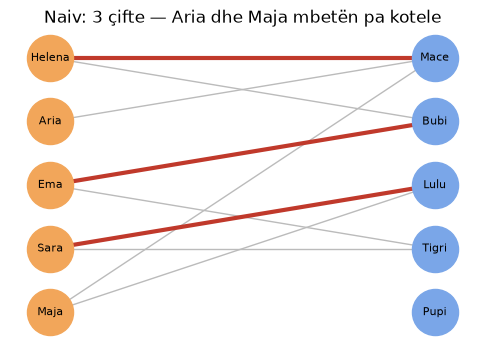

⏳ Grafiku i çiftëzimit maksimum shfaqet pasi të plotësoni Ushtrimin 1.


In [5]:
import networkx as nx
import matplotlib.pyplot as plt

def vizato_dyanesor(preferencat, M, titulli):
    vajzat = list(preferencat)
    kot = [k for k in kotelet]
    pos = {v: (0, -i) for i, v in enumerate(vajzat)}
    pos.update({k: (2.2, -i) for i, k in enumerate(kot)})
    G = nx.Graph()
    G.add_nodes_from(vajzat + kot)
    G.add_edges_from((v, k) for v, l in preferencat.items() for k in l)
    _, ax = plt.subplots(figsize=(6, 4))
    nx.draw_networkx_nodes(G, pos, nodelist=vajzat, node_color="#f2a65a", node_size=1100, ax=ax)
    nx.draw_networkx_nodes(G, pos, nodelist=kot, node_color="#7aa6e8", node_size=1100, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)
    nx.draw_networkx_edges(G, pos, edge_color="#bbb", ax=ax)
    nx.draw_networkx_edges(G, pos, edgelist=list(M.items()), edge_color="#c0392b", width=3, ax=ax)
    ax.set_title(titulli); ax.axis("off"); plt.show()

vizato_dyanesor(preferencat, M_naiv, f"Naiv: {len(M_naiv)} çifte — Aria dhe Maja mbetën pa kotele")
try:
    _v, _f = rrjedha_max(rrjeta_e_ciftezimit(preferencat))
    _M = ciftezimi_nga_rrjedha(_f, preferencat)
    vizato_dyanesor(preferencat, _M, f"Rrjedha max: {len(_M)} çifte")
except NotImplementedError:
    print("⏳ Grafiku i çiftëzimit maksimum shfaqet pasi të plotësoni Ushtrimin 1.")

> **Pyetje:** nisni nga çiftëzimi naiv (Helena–Mace, Ema–Bubi, Sara–Lulu). Rruga rritëse
> $s \to \text{Aria} \to \text{Mace} \to \text{Helena} \to \text{Bubi} \to \text{Ema} \to \text{Tigri} \to t$
> kalon nëpër dy **brinjë kthyese**. Cilat janë? Çfarë "ndërrimi mendjeje" përfaqëson secila?
> Shkruani çiftëzimin që del pas kësaj rritjeje.
>
> Pse **nuk** ka çiftëzim me 5 çifte? *(Ndihmë: sa kotele të ndryshme pëlqejnë të pesë vajzat së bashku?)*

## Ushtrimi 2 — Pse funksionon? Verifikim me forcë brutale

Qeliza më poshtë gjeneron 300 grafe dyanësorë të rastit, gjen çiftëzimin maksimum **duke provuar të gjitha
nënbashkësitë e brinjëve** dhe e krahason me rrjedhën max. Ajo kontrollon edhe pikat 1–4 të slide 85.

In [6]:
import random
from itertools import combinations

def ciftezim_max_brutal(preferencat):
    brinjet = [(v, k) for v, l in preferencat.items() for k in l]
    for r in range(min(len(preferencat), len(brinjet)), 0, -1):
        for nen in combinations(brinjet, r):
            if len({v for v, _ in nen}) == r and len({k for _, k in nen}) == r:
                return r
    return 0

rng = random.Random(10)
for _ in range(300):
    X = [f"x{i}" for i in range(rng.randint(1, 5))]
    Y = [f"y{j}" for j in range(rng.randint(1, 5))]
    pref = {x: [y for y in Y if rng.random() < 0.4] for x in X}
    c = {("s", x): 1 for x in X}
    for x, l in pref.items():
        for y in l:
            c[(x, y)] = 1; c[(y, "t")] = 1
    v, f = rrjedha_max(c)
    assert all(val in (0, 1) for val in f.values())                                    # 1. e plotë: 0 ose 1
    assert all(sum(f.get((x, y), 0) for y in Y) <= 1 for x in X)                       # 2. ≤ 1 për çdo x
    M = [(x, y) for x in X for y in pref[x] if f[(x, y)] == 1]
    assert len({y for _, y in M}) == len(M)                                            # 3. çiftëzim
    assert v == len(M) == ciftezim_max_brutal(pref)                                    # 4. + 5. maksimum
print("300 grafe dyanësorë: rrjedha max = çiftëzimi maksimum në çdo rast.")

300 grafe dyanësorë: rrjedha max = çiftëzimi maksimum në çdo rast.


## Ushtrimi 3 — Lulet dhe buqetat (slides 86–89)

*A është e mundur të realizohen buqetat siç i duam?*

- **Lulet** ($X$): 7 lloje, secili me një sasi në dispozicion — $c(x)$.
- **Buqetat** ($Y$): 6 buqeta, secila me numrin maksimal të luleve — $c(y)$.
- Çdo buqetë pranon vetëm disa lloje lulesh, dhe **të shumtën 10 lule të të njëjtit lloj** — $c(x, y) = 10$.

> Numrat ndjekin modelin e slides 87–89 (p.sh. *"Kemi 10 lule të tilla"*, *"Kjo buqetë mund të ketë 15 lule"*);
> disa vlera janë plotësuar nga ne aty ku figura nuk lexohej.

**Detyra:**
1. `rrjeta_e_caktimit(oferta, kapaciteti, lejohet, limiti)` — ndërtoni rrjetën:
   `("s", lule)` me `oferta[lule]`, `(lule, buqete)` me `limiti` për çdo lule të lejuar, `(buqete, "t")` me `kapaciteti[buqete]`.
2. `realizohen_te_gjitha(...)` — `True` nëse rrjedha max **mbush** të gjitha buqetat ($= \sum_y c(y)$).

In [7]:
oferta = {"Trëndafil i kuq": 10, "Trëndafil rozë": 15, "Trëndafil i bardhë": 15, "Zambak rozë": 15,
          "Tulipan i kuq": 15, "Zambak i bardhë": 15, "Tulipan rozë": 10}
kapaciteti = {"Buqetë e kuqe": 15, "Buqetë rozë": 15, "Buqetë e bardhë": 15,
              "Vetëm trëndafila": 20, "Vetëm tulipanë": 15, "Vetëm zambakë": 15}
lejohet = {
    "Buqetë e kuqe":    ["Trëndafil i kuq", "Tulipan i kuq"],
    "Buqetë rozë":      ["Trëndafil rozë", "Zambak rozë", "Tulipan rozë"],
    "Buqetë e bardhë":  ["Trëndafil i bardhë", "Zambak i bardhë"],
    "Vetëm trëndafila": ["Trëndafil i kuq", "Trëndafil rozë", "Trëndafil i bardhë"],
    "Vetëm tulipanë":   ["Tulipan i kuq", "Tulipan rozë"],
    "Vetëm zambakë":    ["Zambak rozë", "Zambak i bardhë"],
}


def rrjeta_e_caktimit(oferta, kapaciteti, lejohet, limiti=10):
    # PLOTESO
    raise NotImplementedError


def realizohen_te_gjitha(oferta, kapaciteti, lejohet, limiti=10):
    # PLOTESO
    raise NotImplementedError

In [8]:
def _testet():
    c = rrjeta_e_caktimit(oferta, kapaciteti, lejohet)
    assert len(c) == 7 + 14 + 6, f"rrjeta ka 7 + 14 + 6 = 27 brinjë, ju keni {len(c)}"
    assert c[("Tulipan i kuq", "Buqetë e kuqe")] == 10 and c[("Vetëm trëndafila", "t")] == 20
    assert realizohen_te_gjitha(oferta, kapaciteti, lejohet), "me këto sasi, të gjitha buqetat realizohen (95 lule)"
    me_pak = dict(oferta); me_pak["Trëndafil i kuq"] = 5
    assert not realizohen_te_gjitha(me_pak, kapaciteti, lejohet), "me vetëm 5 trëndafila të kuq nuk mjaftojnë"
    assert not realizohen_te_gjitha(oferta, kapaciteti, lejohet, limiti=5), \
        "me limit 5 lule për lloj, buqeta e kuqe (2 lloje) mbush vetëm 10 nga 15"

    v, f = rrjedha_max(c)
    print(f"   Rrjedha max = {v} lule nga {sum(kapaciteti.values())} të mundshme.\n")
    print(f"   {'':<20}" + "".join(f"{y[:12]:>13}" for y in kapaciteti))
    for x in oferta:
        print(f"   {x:<20}" + "".join(f"{(f.get((x, y), 0) or '·'):>13}" if (x, y) in c else f"{'':>13}"
                                    for y in kapaciteti))

kontrollo("Ushtrimi 3 — Lulet dhe buqetat", _testet)

⏳ Ushtrimi 3 — Lulet dhe buqetat: ende pa plotësuar — zëvendësoni `raise NotImplementedError` me kodin tuaj.


> **Krahasoni me slide 89:** *"10 trëndafila të kuq dhe 5 tulipanë të kuq për buqetën e kuqe me 15 lule"*,
> *"Të shumtën 10 trëndafila rozë janë caktuar në buqetën e trëndafilave"*. A gjeni të njëjtat vlera në tabelë?
> A është ky caktim i **vetmi** i mundshëm?

### Kur nuk mjafton një lloj luleje: prerja min tregon ku

Supozojmë se nga çdo lloj kemi me bollëk (30 lule), **përveç** trëndafilave të kuq: vetëm 3.
Rrjedha max nuk arrin 95. Prerja min tregon **ku** është ngushtica — dhe pse asnjë caktim tjetër nuk e zgjidh.

In [9]:
def _demo():
    bollek = {x: 30 for x in oferta}
    bollek["Trëndafil i kuq"] = 3
    c = rrjeta_e_caktimit(bollek, kapaciteti, lejohet)
    v, f = rrjedha_max(c)
    S = prerja_min(c, f)
    print(f"Rrjedha max = {v} nga 95. Prerja min ka kapacitet {sum(c[e] for e in c if e[0] in S and e[1] not in S)}.\n")
    print("Mbushja e buqetave:")
    for y, k in kapaciteti.items():
        print(f"   {y:<18} {f[(y, 't')]:>2} / {k}")
    print("\nBrinjët e prerjes min që nuk janë thjesht 'buqeta → t':")
    for (u, w) in c:
        if u in S and w not in S and w != "t":
            print(f"   {u} → {w}   (kapaciteti {c[(u, w)]})")

try:
    _demo()
except NotImplementedError:
    print("⏳ Ky rezultat shfaqet pasi të plotësoni Ushtrimin 3.")

⏳ Ky rezultat shfaqet pasi të plotësoni Ushtrimin 3.


> **Si lexohet:** buqeta e kuqe pranon vetëm trëndafila të kuq dhe tulipanë të kuq. Kemi 3 trëndafila të kuq, dhe
> nga tulipanët e kuq lejohen të shumtën 10 → $3 + 10 = 13 < 15$. Asnjë rishpërndarje e luleve të tjera nuk e ndryshon
> këtë — prerja e **vërteton**. Dy brinjët e fundit i takojnë buqetës "Vetëm trëndafila", e cila në këtë caktim mbushet
> plot; ato shfaqen sepse prerja min nuk është e vetmja e mundshme.

## Ushtrimi 4 — Modelojeni vetë: grupet e laboratorit

Ky ushtrim nuk ka kod të gatshëm për rrjetën — e ndërtoni **ju**, nga e para.

Departamenti ka 4 grupe laboratori, secili me **3 kompjutera**. Secili nga 10 studentët ka dhënë oraret kur
është i lirë. **A mund të vendoset çdo student në saktësisht një grup?** Nëse jo, sa studentë mund të vendosen
të shumtën, dhe cilët janë "problemi"?

**Detyra:** `sa_studente_vendosen(disponueshmeria, vende_per_grup)` — ndërtoni rrjetën (pa përdorur
`rrjeta_e_caktimit`), ekzekutoni `rrjedha_max` dhe ktheni `(numri, caktimi)` ku `caktimi = {student: grup}`.

In [10]:
disponueshmeria = {
    "Arbër":  ["E hënë 10:00"],
    "Besa":   ["E hënë 10:00"],
    "Dritan": ["E hënë 10:00", "E martë 08:00"],
    "Elira":  ["E hënë 10:00"],
    "Gentian": ["E hënë 10:00", "E martë 08:00"],
    "Ilda":   ["E martë 08:00", "E enjte 14:00"],
    "Klevis": ["E mërkurë 12:00"],
    "Lira":   ["E hënë 10:00"],
    "Mirela": ["E mërkurë 12:00", "E enjte 14:00"],
    "Noel":   ["E enjte 14:00"],
}


def sa_studente_vendosen(disponueshmeria, vende_per_grup=3):
    # PLOTESO: s → student (1), student → grup (1), grup → t (vende_per_grup)
    raise NotImplementedError

In [11]:
def _testet():
    n, caktimi = sa_studente_vendosen(disponueshmeria)
    assert len(caktimi) == n, "numri duhet të përputhet me caktimin"
    assert all(g in disponueshmeria[s] for s, g in caktimi.items()), "një student u vendos në grup ku nuk është i lirë"
    from collections import Counter
    assert max(Counter(caktimi.values()).values()) <= 3, "një grup ka më shumë se 3 studentë"
    assert n == 9, f"vetëm 9 studentë mund të vendosen — ju morët {n}"
    n4, _ = sa_studente_vendosen(disponueshmeria, 4)
    assert n4 == 10, "me 4 kompjutera për grup, të gjithë vendosen"
    print(f"   {n} nga {len(disponueshmeria)} studentë u vendosën:")
    for g in sorted(set(caktimi.values())):
        print(f"     {g}: {', '.join(s for s, x in caktimi.items() if x == g)}")
    print("   Pa grup:", ", ".join(s for s in disponueshmeria if s not in caktimi))

kontrollo("Ushtrimi 4 — Grupet e laboratorit", _testet)

⏳ Ushtrimi 4 — Grupet e laboratorit: ende pa plotësuar — zëvendësoni `raise NotImplementedError` me kodin tuaj.


> **Pyetje:** Arbëri, Besa, Elira dhe Lira janë të lirë **vetëm** të hënën në 10:00 — katër studentë për tre
> kompjutera. Shpjegoni pse 9 është maksimumi, duke gjetur një **prerje** me kapacitet 9.
> Nëse departamenti mund të shtojë **një** kompjuter, në cilin grup duhet ta shtojë?

## Punë në Klasë

**Problemi 1 — Ndërtimi i rrjetës.** Vizatoni rrjetën rrjedhë për vajzat dhe kotelet e Ushtrimit 1 (me $s$ dhe $t$).
Sa kulme dhe sa brinjë ka? Nisni nga çiftëzimi naiv (3 çifte) si rrjedhë, vizatoni rrjetën mbetëse dhe gjeni
**një rrugë rritëse**. Cilat brinja të saj janë kthyese? Çfarë "ndërrimi" përfaqësojnë?

**Problemi 2 — Prerja.** Gjeni një prerje me kapacitet 4 në rrjetën e Problemit 1 dhe shpjegoni pse ajo
**vërteton** që nuk ka çiftëzim me 5 çifte. *(Ndihmë: sa brinjë kotele → $t$ ka rrjeta?)*

**Problemi 3 — Modelim.** Një spital ka 5 mjekë dhe 7 turne nate në javë. Çdo mjek mund të bëjë të shumtën 2 turne,
vetëm në netët kur është i lirë, dhe çdo turn ka nevojë për saktësisht 1 mjek. Vizatoni rrjetën rrjedhë.
Si do ta shtonit kushtin *"asnjë mjek nuk punon dy net radhazi"*? *(Ky kusht është më i vështirë — diskutoni.)*

**Problemi 4.** Pse te problemi i luleve kapaciteti i brinjës (lule → buqetë) është 10, ndërsa te kotelet është 1?
Çfarë do të ndodhte me çiftëzimin nëse kapaciteti $s \to$ vajzë do të ishte 2?

## Pyetje Reflektuese

1. Në këtë laborator nuk shkruam asnjë algoritëm të ri. Pse **modelimi** i një problemi si rrjedhë është po aq i
   vlefshëm sa shkrimi i një algoritmi?
2. Integraliteti (slide 76) ishte një "vëzhgim i dobishëm" në leksion. Pse pa të, reduktimi i çiftëzimit **nuk** do
   të funksiononte?
3. Algoritmi naiv i Ushtrimit 1 dha 3 çifte. A ekziston një renditje e vajzave për të cilën algoritmi naiv jep 4?
   A mund të mbështetemi te kjo në praktikë?
4. Jepni një problem nga jeta juaj (orare, detyra, burime) që mund të modelohet si problem caktimi.